Deep Learning with keras & Tensorflow

Download & Extract the dataset

In [1]:
# In VS Code Notebook, use Python cells just like in Colab. The commands below download the archive, extract it, and print the dataset files so you can verify the data is present.

import urllib.request
import tarfile
import os
import glob

url = 'https://github.com/sadeepj/eth-80/releases/download/0.0.1/eth-80.tar.gz'
dest = 'eth-80.tar.gz'

if not os.path.exists(dest):
    urllib.request.urlretrieve(url, dest)
    print('Downloaded:', dest)
else:
    print('Already downloaded:', dest)

if not os.path.isdir('eth-80'):
    with tarfile.open(dest, 'r:gz') as tar:
        tar.extractall()
    print('Extracted eth-80')
else:
    print('Already extracted: eth-80')

print('\nFiles in current directory:')
for name in sorted(os.listdir('.')):
    if name == dest or name == 'eth-80':
        print(name)

print('\nAll dataset files:')
all_files = sorted(glob.glob('eth-80/**/*', recursive=True))
for path in all_files:
    print(path)

print('\nTotal dataset entries under eth-80:', len(all_files))

Already downloaded: eth-80.tar.gz
Already extracted: eth-80

Files in current directory:
eth-80
eth-80.tar.gz

All dataset files:
eth-80\train_set
eth-80\train_set\apple
eth-80\train_set\apple\apple1
eth-80\train_set\apple\apple1\apple1-000-000.png
eth-80\train_set\apple\apple1\apple1-022-000.png
eth-80\train_set\apple\apple1\apple1-022-090.png
eth-80\train_set\apple\apple1\apple1-022-180.png
eth-80\train_set\apple\apple1\apple1-022-270.png
eth-80\train_set\apple\apple1\apple1-035-045.png
eth-80\train_set\apple\apple1\apple1-035-135.png
eth-80\train_set\apple\apple1\apple1-035-225.png
eth-80\train_set\apple\apple1\apple1-035-315.png
eth-80\train_set\apple\apple1\apple1-045-000.png
eth-80\train_set\apple\apple1\apple1-045-090.png
eth-80\train_set\apple\apple1\apple1-045-180.png
eth-80\train_set\apple\apple1\apple1-045-270.png
eth-80\train_set\apple\apple1\apple1-066-027.png
eth-80\train_set\apple\apple1\apple1-066-063.png
eth-80\train_set\apple\apple1\apple1-066-117.png
eth-80\train_set

Verify that the data is there Correctly Exracted 

In [2]:
from PIL import Image
from IPython.display import display

In [3]:
im = Image.open('eth-80/train_set/dog/dog4/dog4-066-207.png')

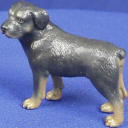

In [4]:
display(im)

In [5]:
import numpy as np
image_array = np.array(im)
image_array.shape
image_array

array([[[ 68,  92, 170],
        [ 76,  92, 176],
        [ 74,  89, 178],
        ...,
        [ 82, 100, 183],
        [ 81, 102, 180],
        [ 82,  99, 183]],

       [[ 72,  89, 176],
        [ 75,  91, 174],
        [ 74,  91, 174],
        ...,
        [ 80, 100, 181],
        [ 81,  99, 181],
        [ 84, 100, 182]],

       [[ 77,  88, 177],
        [ 77,  91, 176],
        [ 74,  90, 174],
        ...,
        [ 79,  99, 180],
        [ 84,  98, 185],
        [ 81,  98, 179]],

       ...,

       [[109, 139, 217],
        [124, 151, 223],
        [116, 139, 218],
        ...,
        [ 89, 113, 196],
        [106, 131, 209],
        [102, 128, 207]],

       [[110, 138, 218],
        [120, 144, 224],
        [115, 137, 218],
        ...,
        [ 97, 127, 205],
        [110, 136, 214],
        [111, 136, 217]],

       [[114, 140, 217],
        [115, 139, 218],
        [117, 139, 219],
        ...,
        [106, 135, 214],
        [109, 132, 215],
        [109, 135, 220]]

Module import & Variable initialization

In [6]:
import numpy as np
import tensorflow as tf 
from tensorflow import keras
from tensorflow.keras import layers
from tensorboardcolab import TensorBoard, TensorBoardColabCallback
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [7]:
# Deimension of our images
img_width, img_height = 128 , 128

In [8]:
train_data_dir = 'eth-80/train_set'
validation_data_dir = 'eth-80/val_set'

np_train_samples = 2952
np_validation_samples = 328

epochs = 50
batch_size = 32

Define the CNN Model 

In [10]:
# New TensorFlow model

input_shape = (img_width, img_height, 3)
model = tf.keras.Sequential()
model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
model.add(tf.keras.layers.MaxPool2D(pool_size=(2, 2)))
model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=(2, 2)))
model.add(tf.keras.layers.MaxPool2D(pool_size=(2, 2)))

model.add(tf.keras.layers.Conv2D(64, (3, 3), activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=(2, 2)))

model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(64, activation='relu'))

d2 = tf.keras.layers.Dense(64, activation='relu')
model.add(d2)

model.add(tf.keras.layers.Dropout(0.5))

d3 = tf.keras.layers.Dense(8, activation='softmax')
model.add(d3)

In [11]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='rmsprop',
    metrics=['accuracy']
)

In [12]:
weights = d3.get_weights()
weights[1].shape

(8,)

Prepare Data Feeders

In [14]:
# this is the augmentation configuration will use for training
train_datagen = ImageDataGenerator(
    rescale=1. / 255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)


In [15]:
# this is the augmentation configuration we will use for testing 
# only rescaling

test_datagen = ImageDataGenerator(rescale=1. / 255)

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical'
)


Found 2952 images belonging to 8 classes.
Found 328 images belonging to 8 classes.
Found 328 images belonging to 8 classes.


Test the data feeders

In [16]:
datum = next(train_generator)
image_batch, label_batch = datum
image_batch.shape
k = 3
image = image_batch[k, ...]
label = label_batch[k, ...]

label

array([0., 0., 0., 1., 0., 0., 0., 0.], dtype=float32)

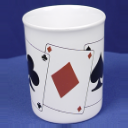

In [19]:
display(Image.fromarray((image * 255).astype(np.uint8).astype(np.uint8)))

In [20]:
image_batch.shape

(32, 128, 128, 3)

In [24]:
import datetime
import os
import shutil

%pip install tensorboard
%load_ext tensorboard

# Clear any logs from previous runs
if os.path.isdir('./logs'):
    shutil.rmtree('./logs')
print('Logs cleared:', not os.path.isdir('./logs'))

log_dir = os.path.join('logs', 'fit', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
print('TensorBoard log dir:', log_dir)


Note: you may need to restart the kernel to use updated packages.
The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard
Logs cleared: True
TensorBoard log dir: logs\fit\20260409-001950


Fit the Model

In [26]:
#tbc = TensorBoardColab()
model.fit(
    train_generator,
    steps_per_epoch=np_train_samples // batch_size,
    epochs=epochs,

    validation_data=validation_generator,
    validation_steps=np_validation_samples // batch_size,
    callbacks=[tensorboard_callback]
)


Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.3462 - loss: 1.6564 - val_accuracy: 0.5406 - val_loss: 1.0546
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 95s 1s/step - accuracy: 0.3462 - loss: 1.6564 - val_accuracy: 0.5406 - val_loss: 1.0546
Epoch 2/50
 1/92 ━━━━━━━━━━━━━━━━━━━━ 15s 168ms/step - accuracy: 0.5938 - loss: 0.9159

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5938 - loss: 0.9159 - val_accuracy: 0.5094 - val_loss: 1.0639
Epoch 3/50
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 44s 474ms/step - accuracy: 0.6041 - loss: 1.0175 - val_accuracy: 0.5719 - val_loss: 0.9429
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 44s 474ms/step - accuracy: 0.6041 - loss: 1.0175 - val_accuracy: 0.5719 - val_loss: 0.9429
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6250 - loss: 0.7887 - val_accuracy: 0.4688 - val_loss: 0.9576
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6250 - loss: 0.7887 - val_accuracy: 0.4688 - val_loss: 0.9576
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 35s 383ms/step - accuracy: 0.6962 - loss: 0.7644 - val_accuracy: 0.6500 - val_loss: 0.7256
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 35s 383ms/step - accuracy: 0.6962 - loss: 0.7644 - val_accuracy: 0.6500 - val_loss: 0.7256
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.7188 - loss: 0.6824 - val_accuracy: 0.

In [ ]:
%pip uninstall tensorboard -y
%pip install tensorboard
%tensorboard --logdir logs/fit

Save the weights

In [32]:
model.save_weights('saved_weights.weights.h5')

In [ ]:
model.load_weights('saved_weights.weights.h5')

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'source_file.weights.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)